<a href="https://colab.research.google.com/github/abhaypanchal874-dev/practice-day/blob/main/Titanic_quest_updated2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset into a Pandas
df = pd.read_csv('train.csv')


df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# 1. Fill missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Fill missing 'Embarked' values with the most common port (mode)
# 'S' is the most frequent port in this dataset
df['Embarked'] = df['Embarked'].fillna('S')

# 3. The 'Cabin' column is missing a lot of data.
# For now, we can drop it since it's hard to accurately guess.
df = df.drop('Cabin', axis=1)

# Check our work to make sure no missing values remain
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# View basic statistical details like percentiles, mean, min, and max
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Calculate the 99th percentile for Fare
upper_limit = df['Fare'].quantile(0.99)

# Cap (clip) any fares higher than the upper limit down to the upper limit
df['Fare'] = df['Fare'].clip(upper=upper_limit)

# View the new statistics for the Fare column to confirm it worked
df[['Fare']].describe()

,Fare
count,891.000000
mean,31.224767
std,42.524125
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,249.006220


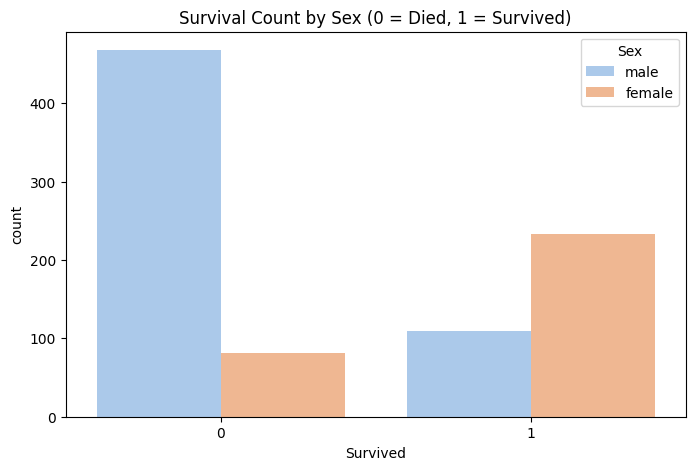

In [ ]:
# Set the size of the figure
plt.figure(figsize=(8, 5))

# Create a bar chart grouping by survival and splitting by sex
sns.countplot(data=df, x='Survived', hue='Sex', palette='pastel')
plt.title('Survival Count by Sex (0 = Died, 1 = Survived)')
plt.show()

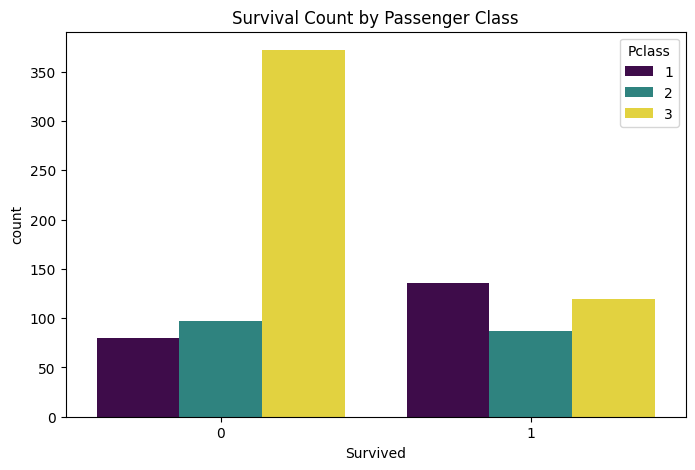

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Survived', hue='Pclass', palette='viridis')
plt.title('Survival Count by Passenger Class')
plt.show()

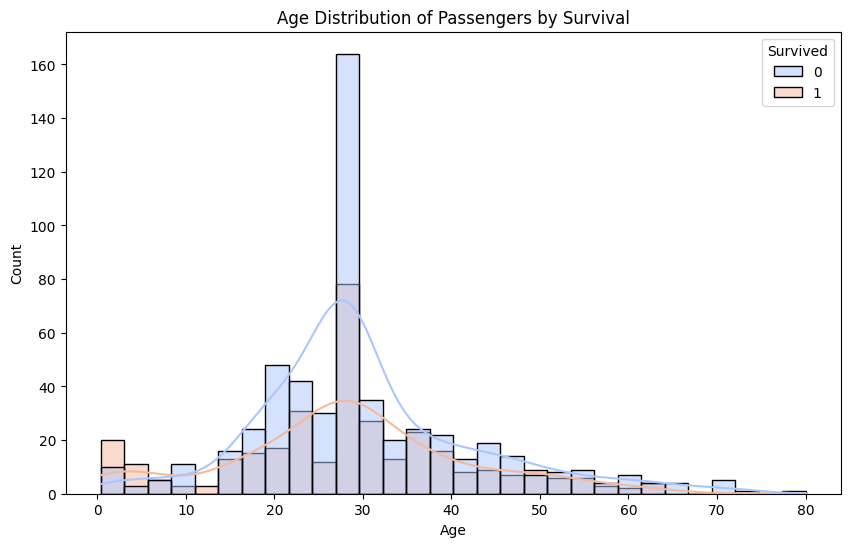

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='coolwarm', bins=30)
plt.title('Age Distribution of Passengers by Survival')
plt.show()

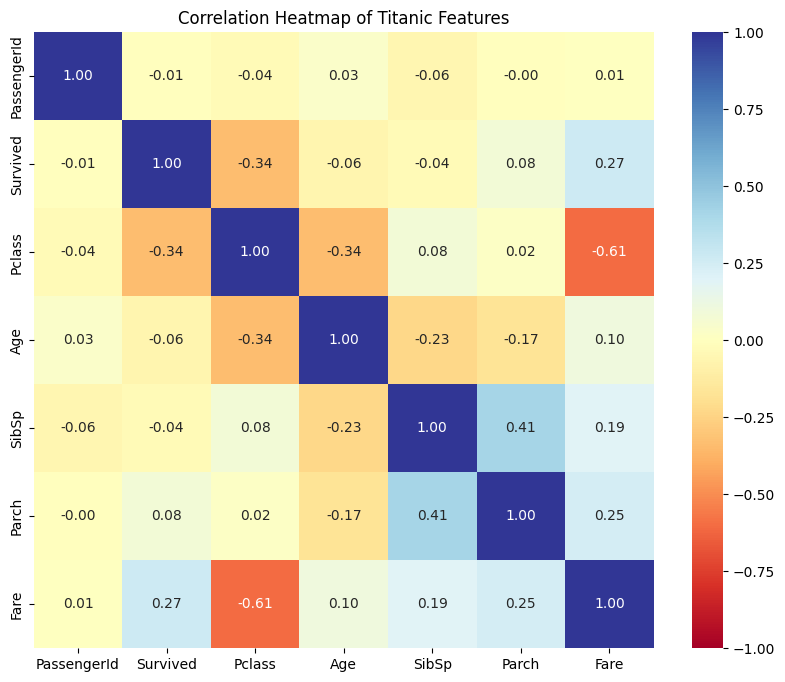

In [ ]:
plt.figure(figsize=(10, 8))

# Filter the dataframe to only include numeric columns for the math to work
numeric_df = df.select_dtypes(include=[np.number])

# Create the heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Titanic Features')
plt.show()